# Ames House Price Prediction
Notebook reviewed for structure, clarity, and reproducibility.


# House Price Prediction (Ames Housing Dataset) 

## Data Loading and Initial inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
house_df = pd.read_csv("../data/data.csv")
house_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
house_df.shape

(1460, 81)

In [4]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## EDA and Target Analysis

>The target variable we are looking for and will try to predict is __SalePrice__.

Let's do a quick inspection of the __SalePrice__ column.

In [5]:
house_df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

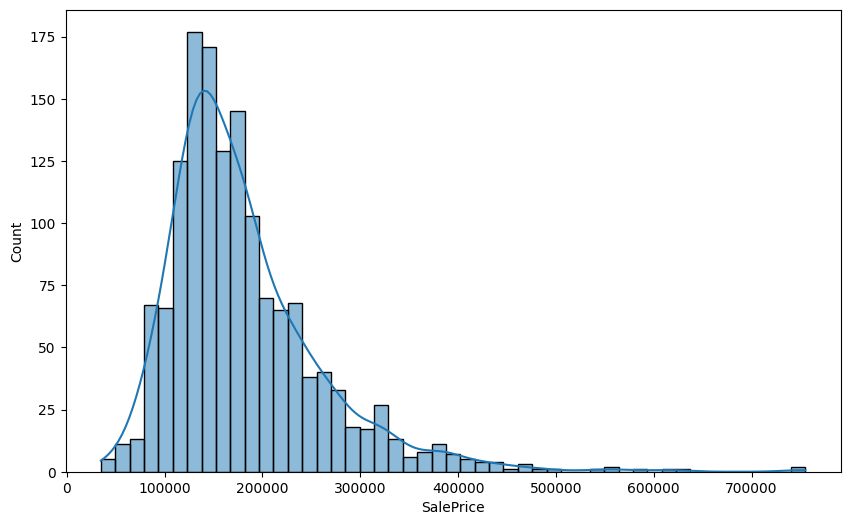

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(house_df['SalePrice'], kde=True)
plt.show()

From the above inspection we can conclude the following,

>1. Mean > Median (This indicates skewness)
>2. The histogram plot shows us that the data is __Right Skewed__

### Countering the RightSkew
- To counter this skewness we apply __log__ to the SalePrice column
- This squashes the large numbers a lot more than the small numbers and hence balancing out the distribution.
- We save the result in a new column called as __'log_SalePrice'__

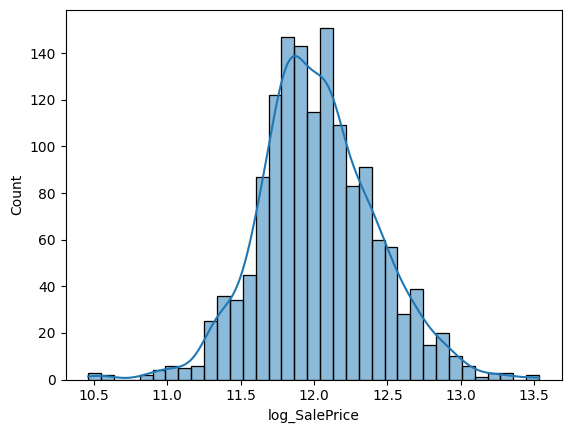

In [7]:
house_df['log_SalePrice'] = np.log(house_df['SalePrice'])
sns.histplot(house_df['log_SalePrice'], kde=True)
plt.show()

In [8]:
print(f"Skewness before applying log: {house_df['SalePrice'].skew()}")
print(f"Skewness after applying log: {house_df['log_SalePrice'].skew()}")

Skewness before applying log: 1.8828757597682129
Skewness after applying log: 0.12133506220520406


## Data Cleaning and Imputation 

In [9]:
null_percent = house_df.isnull().sum()/len(house_df)*100
null_percent = null_percent[null_percent > 0].sort_values(ascending=False)
null_percent

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

- From the dataset description we know that many categorical columns have 'NA' values which are meant to be __None__.
- We are going to impute those values with __None__.


In [10]:
cols_fill_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in cols_fill_none:
    house_df[col] = house_df[col].fillna('None')

In [11]:
null_percent = house_df.isnull().sum()/len(house_df)*100
null_percent = null_percent[null_percent > 0].sort_values(ascending=False)
null_percent

LotFrontage    17.739726
GarageYrBlt     5.547945
MasVnrArea      0.547945
Electrical      0.068493
dtype: float64

- For the rest of the columns, we are going to impute the 'Na' with the most appropriate values. 

In [12]:
house_df['LotFrontage'] = house_df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

In [13]:
house_df['MasVnrArea'] = house_df['MasVnrArea'].fillna(0)

In [14]:
house_df['GarageYrBlt'] = house_df['GarageYrBlt'].fillna(0)

In [15]:
house_df['Electrical'] = house_df['Electrical'].fillna(house_df['Electrical'].mode()[0])

In [16]:
null_percent = house_df.isnull().sum()/len(house_df)*100
null_percent = null_percent[null_percent > 0].sort_values(ascending=False)
null_percent

Series([], dtype: float64)

## Feature Engineering

Creating two new features,

1. __'TotalSF'__ : This is a super-feature which is just the sum of all Area measurements of the House.
2. __'HouseAge'__: This is the Age of the house from when it was built to when it was sold. 

In [17]:
house_df['TotalSF'] = house_df[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']].sum(axis=1)
house_df['TotalSF'].head()

0    2566
1    2524
2    2706
3    2473
4    3343
Name: TotalSF, dtype: int64

In [18]:
house_df['HouseAge'] = house_df['YrSold'] - house_df['YearBuilt']
house_df['HouseAge'].head()

0     5
1    31
2     7
3    91
4     8
Name: HouseAge, dtype: int64

In [19]:
house_df[['TotalSF', 'HouseAge', 'SalePrice']].corr()

,TotalSF,HouseAge,SalePrice
TotalSF,1.000000,-0.347892,0.78226
HouseAge,-0.347892,1.000000,-0.52335
SalePrice,0.782260,-0.523350,1.00000


>The above correlation table shows us that both of the newly created features have a significant correlation with the target variable.

## Preprocessing (Encoding & Scaling)

In [20]:
house_df = house_df.drop('Id', axis=1)

### Encoding the categorical columns using one-hot encoding

In [21]:
house_df_final = pd.get_dummies(house_df, drop_first=True)

In [22]:
house_df_final.shape

(1460, 263)

In [23]:
house_df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 263 entries, MSSubClass to SaleCondition_Partial
dtypes: bool(223), float64(4), int64(36)
memory usage: 774.3 KB


### Train Test Split

In [24]:
y = house_df_final['log_SalePrice']
X = house_df_final.drop(['SalePrice', 'log_SalePrice'], axis=1)

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
print(X_train.shape)
print(X_test.shape)

(1168, 261)
(292, 261)


### Scaling using the StandardScaler

In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [28]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [29]:
X_train_scaled['TotalSF'].mean()

np.float64(1.429602250887188e-16)

## Model Training 

### Linear Regression

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [31]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

LinearRegression()

In [32]:
y_pred = lin_reg.predict(X_test_scaled)

In [33]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

RMSE: 4454299774.424393
R2 Score: -1.0632019945136538e+20


>We see a very bad performance by the LinearRegression model,
This is because the model is assigning really high weights to some features do to the __*"Exploding Weights"*__ Problem which occurs due to Multicollinearity.

>Solution for this is __Ridge Regression__ or __L2 Regularization__.

### Ridge Regression or L2 Regularization (Linear)

In [34]:
from sklearn.linear_model import Ridge

In [35]:
ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train_scaled, y_train)

Ridge(alpha=10)

In [36]:
y_pred = ridge_model.predict(X_test_scaled)

In [37]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

RMSE: 0.15633273901474878
R2 Score: 0.8690345398483518


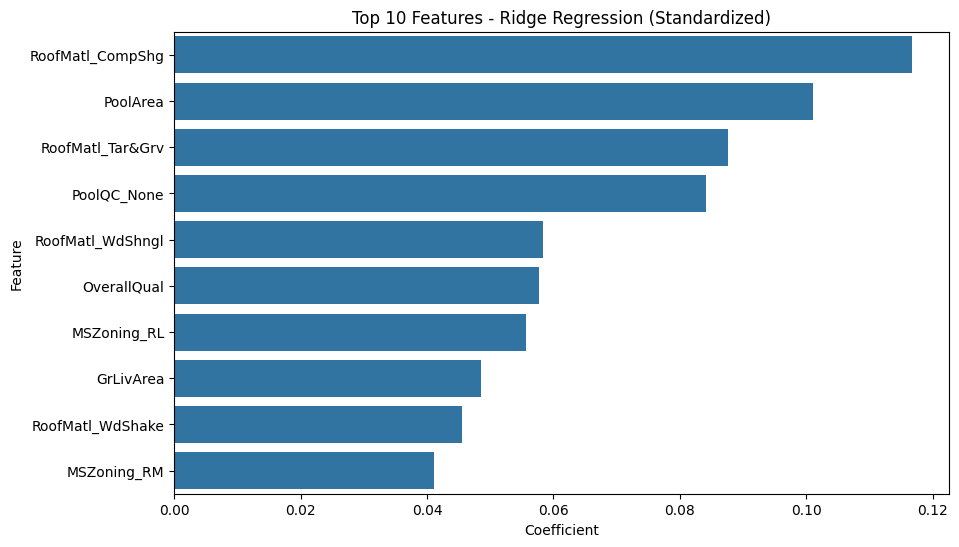

In [38]:
# 1. Get coefficients
ridge_coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': ridge_model.coef_
})

# 2. Create a new column for the Absolute Value (Magnitude)
ridge_coefs['Abs_Coefficient'] = ridge_coefs['Coefficient'].abs()

# 3. Sort by Magnitude
ridge_coefs = ridge_coefs.sort_values(by='Abs_Coefficient', ascending=False)

# 4. Plot
plt.figure(figsize=(10, 6))
# We plot the raw 'Coefficient' to see the Direction (+/-)
sns.barplot(x='Coefficient', y='Feature', data=ridge_coefs.head(10))
plt.title('Top 10 Features - Ridge Regression (Standardized)')
plt.show()

>This model achieved an **R2 Score of 0.869**. However, an analysis of the coefficients revealed that the model is over-sensitive to rare categorical features (e.g., specific Roof Materials), making it potentially unstable for real-world deployment.

### Random Forest (Ensemble)

In [39]:
from sklearn.ensemble import RandomForestRegressor

In [40]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [41]:
y_pred = rf_model.predict(X_test_scaled)

In [42]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

RMSE: 0.14855624358683733
R2 Score: 0.8817397704312309


>Random Forest Model has the highest R2 score and the lowest RMSE, it also identifies that __Size__ and __Quality__ are the primary drivers of value which makes it the winner.

####  Determining the relationship between the house features and how the price varies

Since we trained the Random Forest model with good prediction capabilities, now we need to know exactly which features are more important in making the predictions.

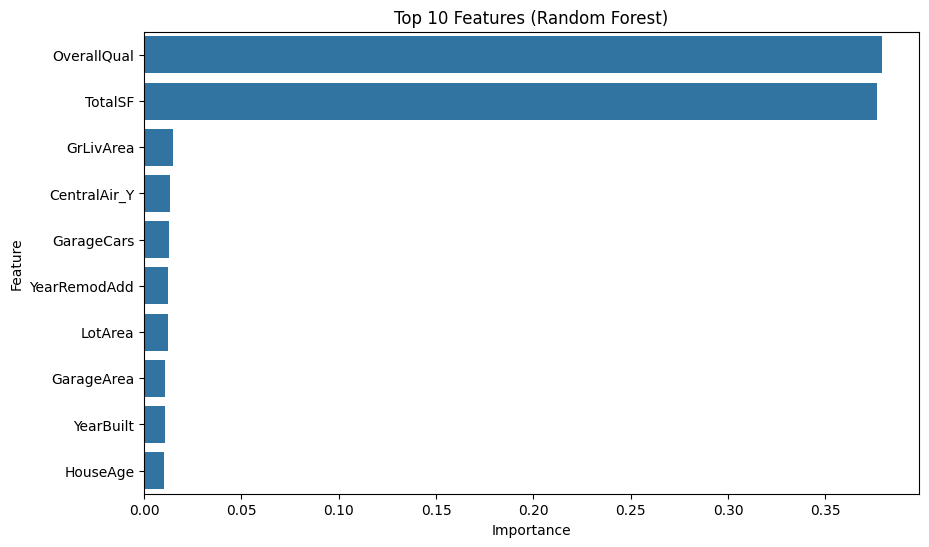

In [43]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title('Top 10 Features (Random Forest)')
plt.show()

## Reversion of the target variable back to dollars $.

Since we used log to squash the numbers, now we need to use the exponential function to revert them back

In [44]:
# Convert predictions back to dollars
y_pred_dollar = np.exp(rf_model.predict(X_test_scaled))

# Convert actual test values back to dollars
y_test_dollar = np.exp(y_test)

In [45]:
rmse_dollar = np.sqrt(mean_squared_error(y_test_dollar, y_pred_dollar))
print(f"RMSE in Dollars: ${rmse_dollar:,.2f}")

RMSE in Dollars: $29,731.12


### Comparison between the Acutal values and the predicted values

In [46]:
comparison = pd.DataFrame({
    'Actual': y_test_dollar, 
    'Predicted': y_pred_dollar, 
    'Difference': y_test_dollar - y_pred_dollar
})
print(comparison.head(20))

        Actual      Predicted     Difference
892   154500.0  141603.065099   12896.934901
1105  325000.0  325713.575360    -713.575360
413   115000.0  111759.569066    3240.430934
522   159000.0  152567.592298    6432.407702
1036  315500.0  312364.492886    3135.507114
614    75500.0   85199.252143   -9699.252143
218   311500.0  200037.979813  111462.020187
1160  146000.0  151690.367447   -5690.367447
649    84500.0   86114.035073   -1614.035073
887   135500.0  131428.159545    4071.840455
576   145000.0  154450.953046   -9450.953046
1252  130000.0  118813.502712   11186.497288
1061   81000.0  110145.278619  -29145.278619
567   214000.0  214864.030889    -864.030889
1108  181000.0  177479.884831    3520.115169
1113  134500.0  130085.522642    4414.477358
168   183500.0  198787.444315  -15287.444315
1102  135000.0  134183.885215     816.114785
1120  118400.0  111349.307102    7050.692898
67    226000.0  213058.374918   12941.625082


# Executive Summary & Project Report

### 1. Model Comparison & Selection
We trained and evaluated two advanced regression models to predict house prices:
*   **Ridge Regression (Linear):** Achieved an **R2 Score of 0.869**. However, an analysis of the coefficients revealed that the model was over-sensitive to rare categorical features (e.g., specific Roof Materials), making it potentially unstable for real-world deployment.
*   **Random Forest (Ensemble):** Achieved an **R2 Score of 0.88** and an **RMSE of 0.147**. This model demonstrated superior robustness, correctly identifying fundamental property attributes (Size and Quality) as the primary drivers of value.

**Conclusion:** We recommend the **Random Forest** model for production. It offers high accuracy (explaining 88% of price variance) while maintaining interpretability and resistance to outliers.

### 2. Key Drivers of House Prices
Based on the Random Forest feature importance analysis, the market value of a home in Ames is driven primarily by two factors, which significantly outweigh all others:
1.  **Overall Quality (`OverallQual`):** The material and finish quality of the home.
2.  **Total Living Area (`TotalSF`):** The combined square footage of the basement, first, and second floors.
3.  **Above Grade Living Area (`GrLivArea`):** The square footage of the house excluding the basement.

### 3. Recommendations for Stakeholders
*   **For Sellers:** Investments in "Quality" (modern finishes, materials) and "Size" (finishing basements to increase Total SF) yield the highest return on investment. Niche features like specific roof types or fences have negligible impact on the final sale price.
*   **For Buyers:** The market heavily premiums "High Quality" finishes. Buyers looking for value should target properties with high square footage (`TotalSF`) but lower cosmetic quality ratings, as these assets are currently undervalued relative to their potential.

### 4. Challenges & Technical Solutions
*   **Skewed Target Variable:** The `SalePrice` was highly right-skewed. We applied a **Log Transformation** to normalize the distribution, improving model performance.
*   **Missing Data:** Key columns like `PoolQC` contained 99% missing values. We identified that these were not errors but indicated the *absence* of a feature. We used **Contextual Imputation** (filling "None") rather than dropping the data.
*   **Feature Engineering:** We created a composite feature, `TotalSF`, which proved to be the single most predictive variable in the dataset, outperforming the raw data columns.